In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm


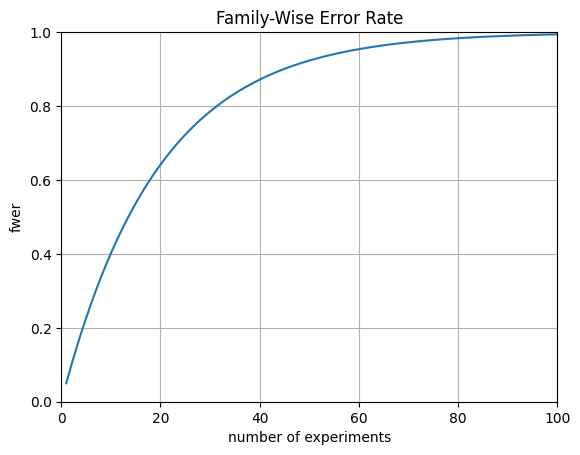

In [2]:

alpha = 0.05  # significance level: probability of type-I error
confidence_level = 1 - alpha  # probability of correctly not rejecting null hypothesis
array_experiments = np.arange(1, 101)  # enumerate all experiments 1-100
no_errors = confidence_level ** array_experiments  # probability of no errors in 'n' experiments
array_fwer = 1 - no_errors  # family-wise error rate: probability of at least one type-I error

# this plot shows that with increase of number of experiments,
# probability of getting at least one type-I error increases very fast
plt.plot(array_experiments, array_fwer)
plt.grid()
plt.xlim([0, 100])
plt.ylim([0, 1])
plt.xlabel('number of experiments')
plt.ylabel('fwer')
plt.title('Family-Wise Error Rate')
plt.show()


In [3]:

# we want to empirically assess FWER
# we can do this simultaneously running multiple A/A-tests and counting type-I errors
# when null-hypothesis is true, p-values are uniformly distributed
# therefore, instead of doing actual A/A-tests, we can sample p-values from uniform distribution
alpha = 0.05  # significance level
n_aa_tests = 50  # number of A/A-tests in one repetition
n_repetitions = 10 ** 4  # number of repetitions

# generate a list of 'n_repetitions' arrays of 'n_aa_tests' p-values
list_pvalues = [np.random.uniform(0, 1, n_aa_tests) for _ in range(n_repetitions)]

# for each array of p-values:
# 0 if no type-I errors
# 1 if at least one type-I error
list_errors = [int((pvalues < alpha).sum() > 0) for pvalues in list_pvalues]

# share of repetitions with errors, i.e. FWER
# FWER ~= 0.923, i.e. the same as in the plot above
fwer = np.mean(list_errors)
print(f'FWER = {fwer:0.3f}')


FWER = 0.922


In [11]:

def bonferroni_correction(pvals, alpha=0.05):
    """
    Perform Bonferroni correction on p-values

    :param pvals: array of original p-values from multiple tests
    :param alpha: desired family-wise error rate

    :return:
    array of corrected p-values
    """
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)

    alpha_corrected = alpha / n
    reject = pvals < alpha_corrected
    pvals_corrected = np.minimum(pvals * n, 1.0)

    return reject, pvals_corrected, alpha_corrected


def compare_bonferroni_implementations(pvals, alpha=0.05, n_values_to_show=5):
    reject, pvals_corrected, alpha_corrected = (
        bonferroni_correction(pvals, alpha))

    print('CUSTOM BONFERRONI METHOD')
    print('alpha original:        ', alpha)
    print('alpha corrected:       ', alpha_corrected)
    print('p-values original:     ', pvals[:n_values_to_show])
    print('p-values corrected:    ', pvals_corrected[:n_values_to_show])
    print('reject null-hypothesis:', reject[:n_values_to_show])

    reject, pvals_corrected, _, alpha_corrected_bonferroni = (
        sm.stats.multipletests(pvals, alpha=alpha, method='bonferroni'))

    print('\nSTATSMODELS BONFERRONI METHOD')
    print('alpha original:        ', alpha)
    print('alpha corrected:       ', alpha_corrected_bonferroni)
    print('p-values original:     ', pvals[:n_values_to_show])
    print('p-values corrected:    ', pvals_corrected[:n_values_to_show])
    print('reject null-hypothesis:', reject[:n_values_to_show])
    print('')

    reject, pvals_corrected, _, alpha_corrected_bonferroni = (
        sm.stats.multipletests(pvals, alpha=alpha, method='holm'))

    print('\nSTATSMODELS HOLM METHOD')
    print('alpha original:        ', alpha)
    print('alpha corrected:       ', alpha_corrected_bonferroni)
    print('p-values original:     ', pvals[:n_values_to_show])
    print('p-values corrected:    ', pvals_corrected[:n_values_to_show])
    print('reject null-hypothesis:', reject[:n_values_to_show])
    print('')


compare_bonferroni_implementations(list_pvalues[0])

# for each array of p-values:
# 0 if no type-I errors
# 1 if at least one type-I error
list_errors = [
    ((sm.stats.multipletests(pvals, alpha=alpha, method='bonferroni')[0]).sum() > 0).astype(int)
    for pvals in list_pvalues]

# share of repetitions with errors, i.e. FWER
# FWER ~= 0.05, i.e. FWER is corrected!!!
fwer = np.mean(list_errors)
print(f'FWER = {fwer:0.3f}')


CUSTOM BONFERRONI METHOD
alpha original:         0.05
alpha corrected:        0.001
p-values original:      [0.94530745 0.41158948 0.30548855 0.82710663 0.70728839]
p-values corrected:     [1. 1. 1. 1. 1.]
reject null-hypothesis: [False False False False False]

STATSMODELS BONFERRONI METHOD
alpha original:         0.05
alpha corrected:        0.001
p-values original:      [0.94530745 0.41158948 0.30548855 0.82710663 0.70728839]
p-values corrected:     [1. 1. 1. 1. 1.]
reject null-hypothesis: [False False False False False]


STATSMODELS HOLM METHOD
alpha original:         0.05
alpha corrected:        0.001
p-values original:      [0.94530745 0.41158948 0.30548855 0.82710663 0.70728839]
p-values corrected:     [1. 1. 1. 1. 1.]
reject null-hypothesis: [False False False False False]

FWER = 0.047
